In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load clean data
df = pd.read_csv('../data/processed/df_clean.csv')

# Load feature columns
with open('../data/processed/feature_cols.json') as f:
    feature_cols = json.load(f)

print(f"Shape : {df.shape}")
print(f"Features : {len(feature_cols)}")
df.head(3)

Shape : (404800, 27)
Features : 25


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,0,1,3,82600.0,0,0.9,2,0,20000.0,...,1,23700.0,660.0,303200.0,70200.0,3,850000.0,15,0,500.0
1,38.0,0,1,1,21500.0,0,7.0,4,1,0.0,...,1,4100.0,714.0,92500.0,26900.0,0,128000.0,19,0,700.0
2,38.0,1,1,3,86100.0,0,5.8,1,2,0.0,...,0,0.0,650.0,672100.0,324200.0,4,306000.0,16,2,27775.0


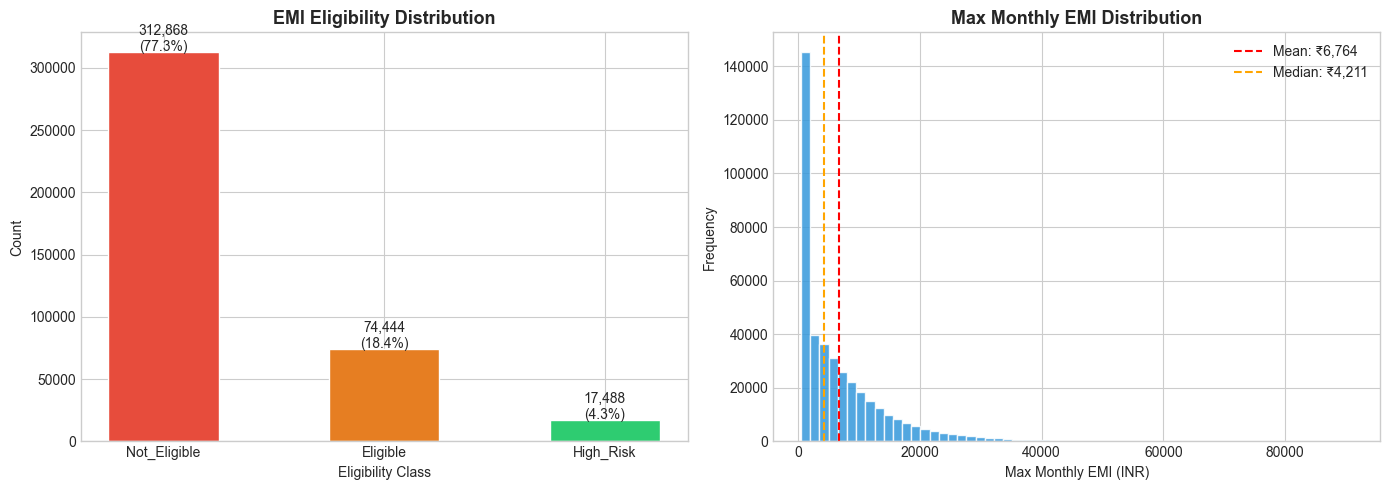

In [2]:
# Decode targets back to labels for readable plots
eligibility_map = {0: 'Not_Eligible', 1: 'High_Risk', 2: 'Eligible'}
df['emi_eligibility_label'] = df['emi_eligibility'].map(eligibility_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Classification target ---
colors = ['#e74c3c', '#e67e22', '#2ecc71']
counts = df['emi_eligibility_label'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('EMI Eligibility Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Eligibility Class')
axes[0].set_ylabel('Count')
for i, (val) in enumerate(counts.values):
    axes[0].text(i, val + 500, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

# --- Plot 2: Regression target ---
axes[1].hist(df['max_monthly_emi'], bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(df['max_monthly_emi'].mean(),   color='red',    linestyle='--', linewidth=1.5,
                label=f'Mean: ₹{df["max_monthly_emi"].mean():,.0f}')
axes[1].axvline(df['max_monthly_emi'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: ₹{df["max_monthly_emi"].median():,.0f}')
axes[1].set_title('Max Monthly EMI Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Max Monthly EMI (INR)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/target_distribution.png', dpi=120)
plt.show()

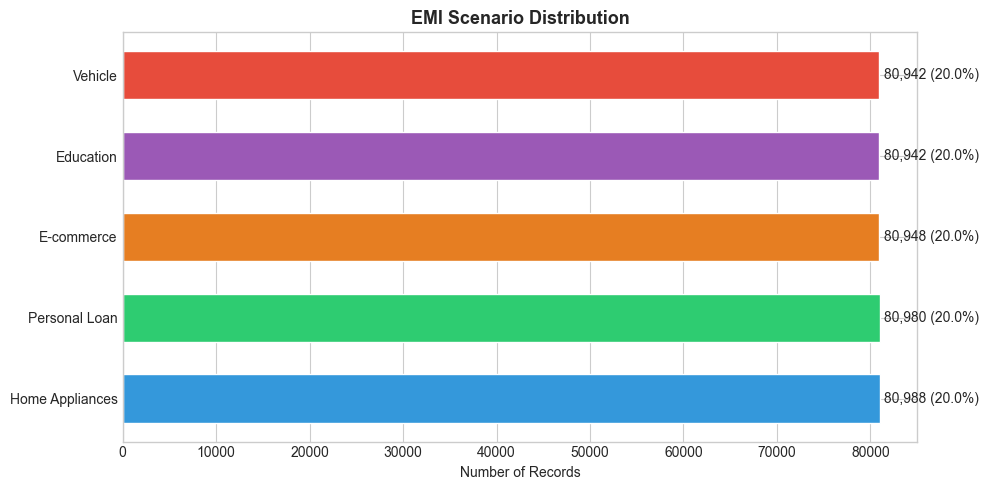

In [3]:
# EMI distribution
scenario_map = {
    0: 'E-commerce', 1: 'Home Appliances',
    2: 'Vehicle', 3: 'Personal Loan', 4: 'Education'
}
df['scenario_label'] = df['emi_scenario'].map(scenario_map)

fig, ax = plt.subplots(figsize=(10, 5))
counts = df['scenario_label'].value_counts()
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=10)

ax.set_title('EMI Scenario Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Records')
plt.tight_layout()
plt.savefig('../data/processed/scenario_distribution.png', dpi=120)
plt.show()

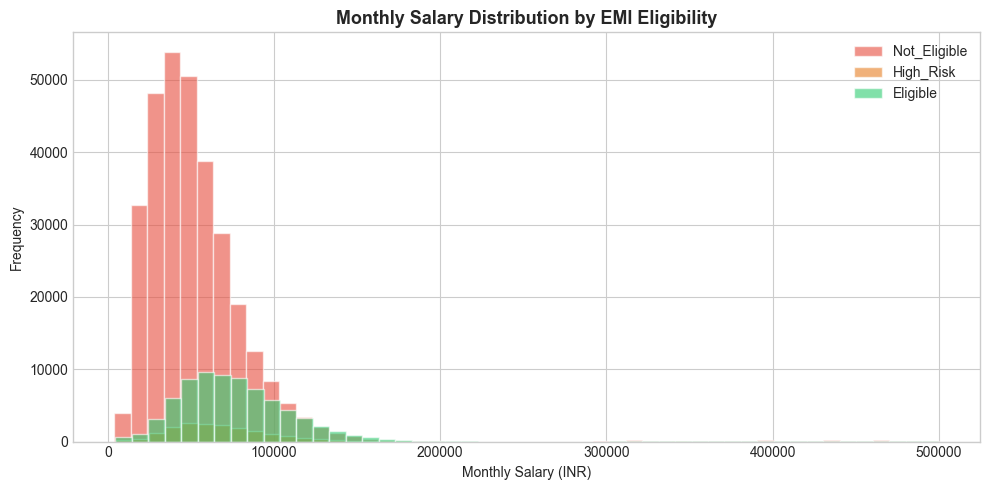

In [4]:
# SAlary distribution by eligibility
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'Not_Eligible': '#e74c3c', 'High_Risk': '#e67e22', 'Eligible': '#2ecc71'}
for label, color in colors.items():
    subset = df[df['emi_eligibility_label'] == label]['monthly_salary']
    ax.hist(subset, bins=50, alpha=0.6, label=label, color=color, edgecolor='white')

ax.set_title('Monthly Salary Distribution by EMI Eligibility', fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Salary (INR)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/salary_by_eligibility.png', dpi=120)
plt.show()

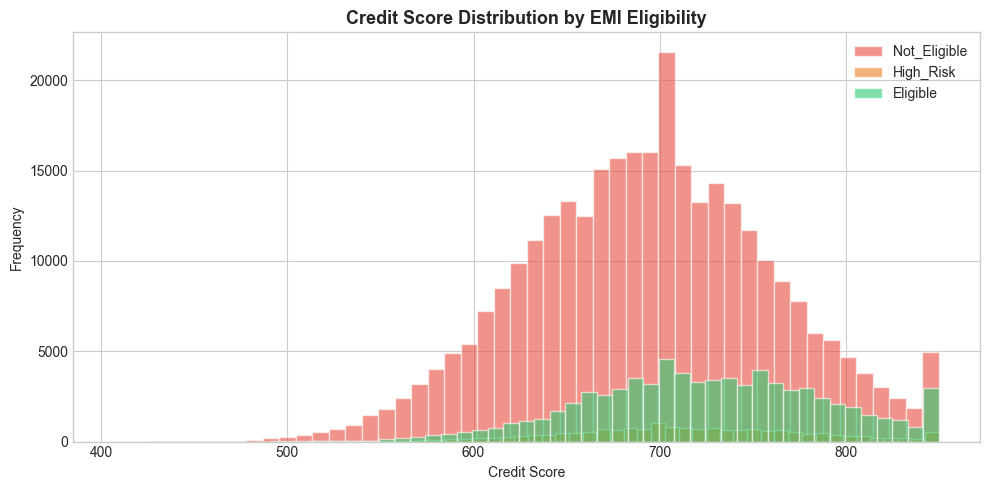

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, color in colors.items():
    subset = df[df['emi_eligibility_label'] == label]['credit_score']
    ax.hist(subset, bins=50, alpha=0.6, label=label, color=color, edgecolor='white')

ax.set_title('Credit Score Distribution by EMI Eligibility', fontsize=13, fontweight='bold')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/creditscore_by_eligibility.png', dpi=120)
plt.show()

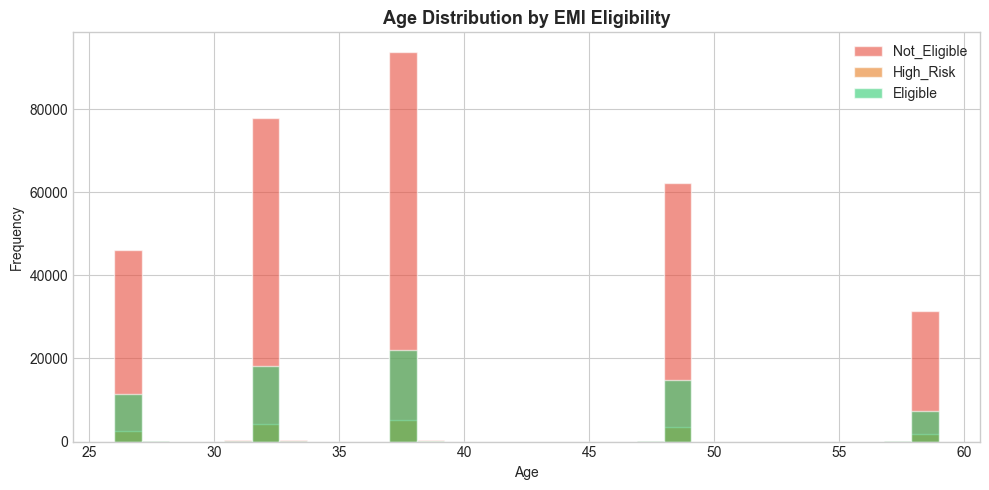

In [ ]:
# Age distribution by eligibility
fig, ax = plt.subplots(figsize=(10, 5))

for label, color in colors.items():
    subset = df[df['emi_eligibility_label'] == label]['age']
    ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')

ax.set_title('Age Distribution by EMI Eligibility', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/age_by_eligibility.png', dpi=120)
plt.show()

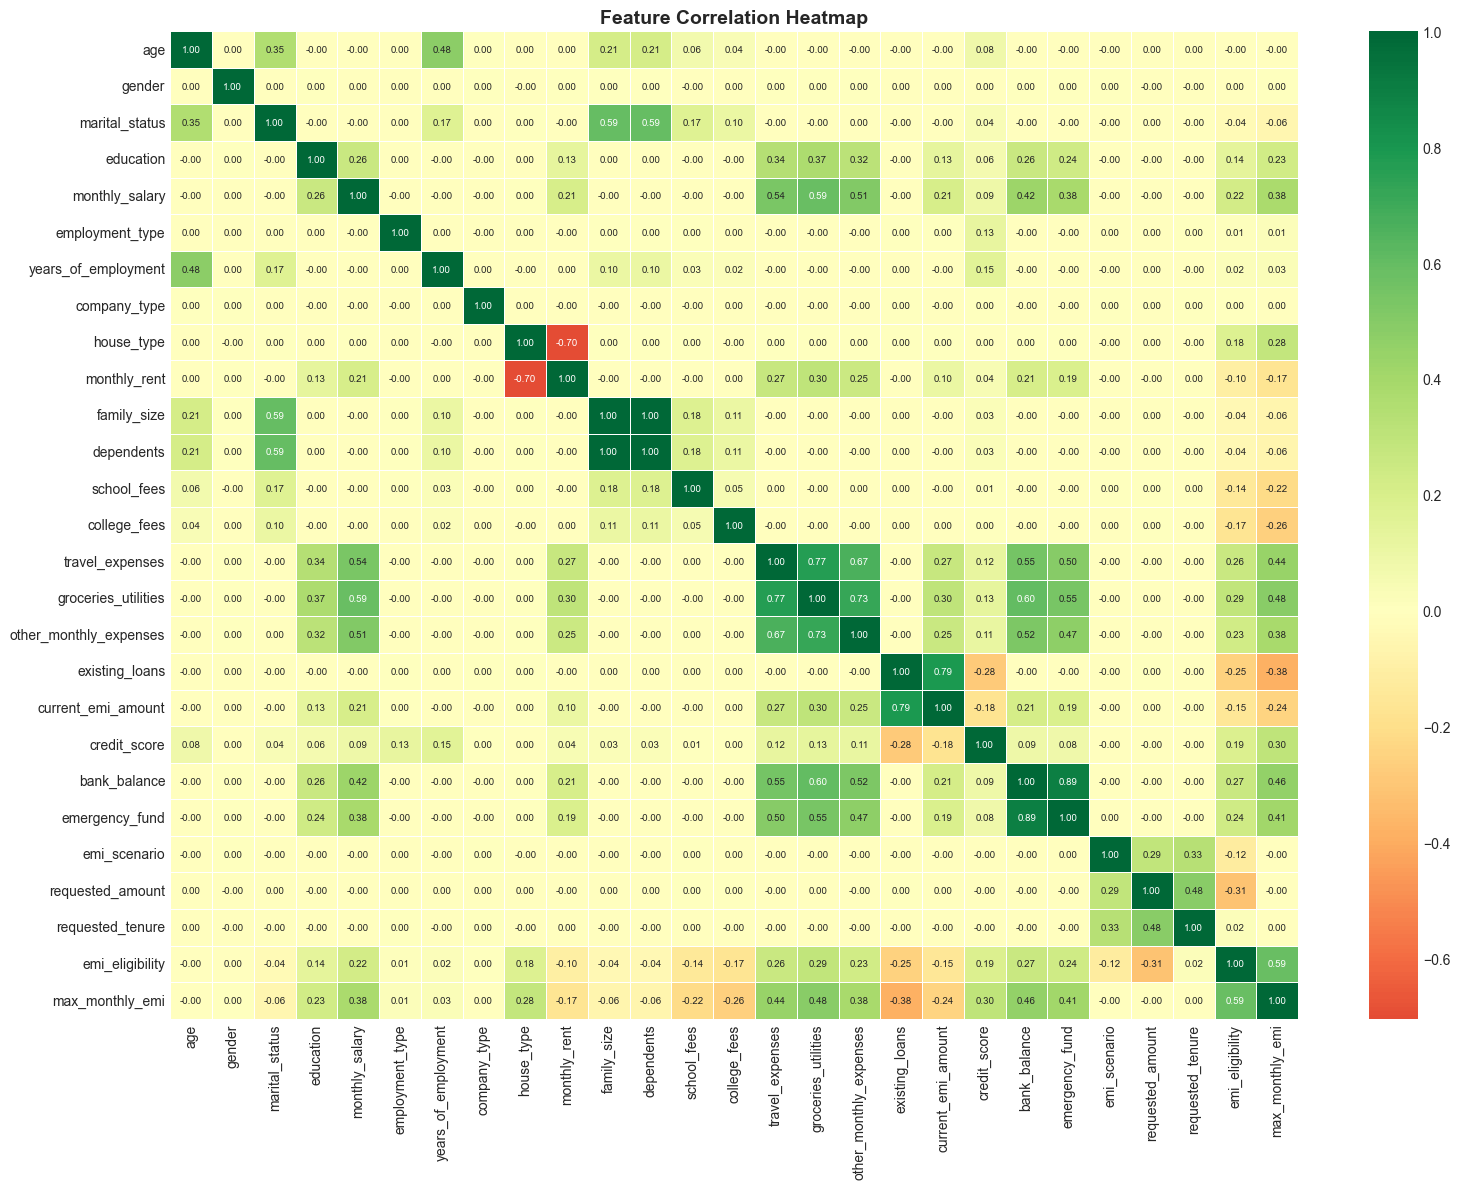

In [7]:
# corelation heatmap
fig, ax = plt.subplots(figsize=(16, 12))

corr = df[feature_cols + ['emi_eligibility', 'max_monthly_emi']].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=120)
plt.show()

In [8]:
df = df.drop(columns=['family_size'])
feature_cols = [c for c in feature_cols if c != 'family_size']

print(f"Features remaining : {len(feature_cols)}")
print(feature_cols)

Features remaining : 24
['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'years_of_employment', 'company_type', 'house_type', 'monthly_rent', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount', 'requested_tenure']


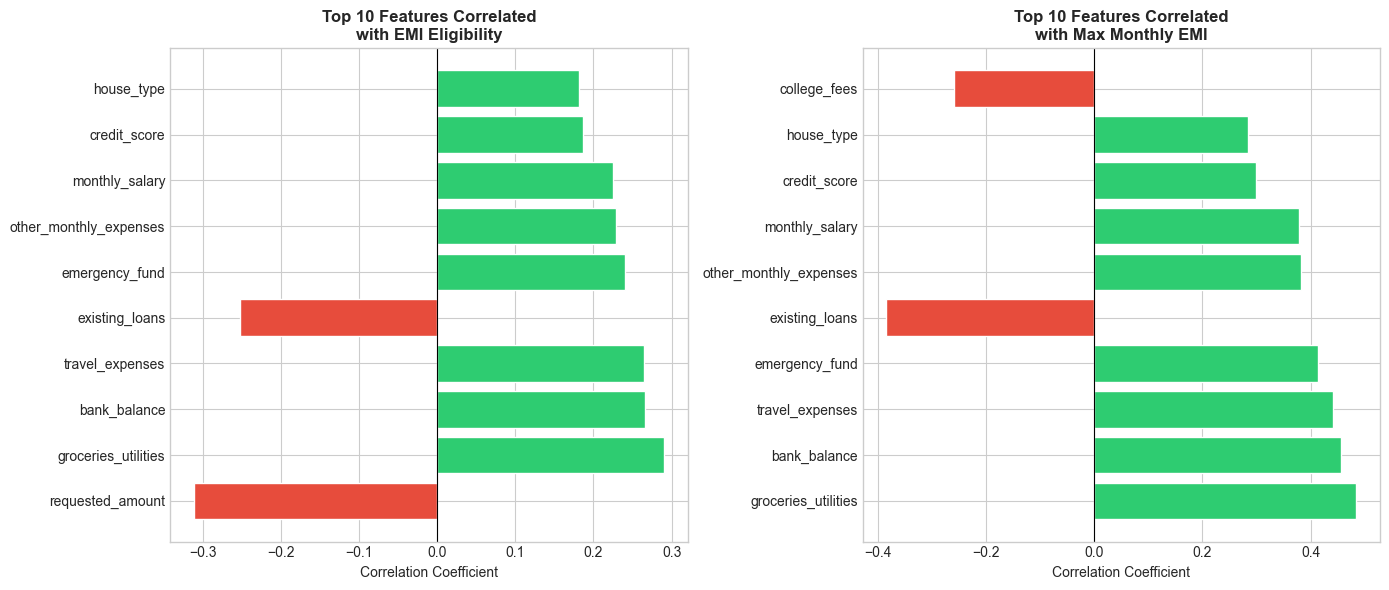

In [9]:
# Top features corelated with targets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Correlation with emi_eligibility
corr_class = df[feature_cols + ['emi_eligibility']].corr()['emi_eligibility'].drop('emi_eligibility')
corr_class = corr_class.sort_values(key=abs, ascending=False).head(10)

colors_c = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_class.values]
axes[0].barh(corr_class.index, corr_class.values, color=colors_c, edgecolor='white')
axes[0].set_title('Top 10 Features Correlated\nwith EMI Eligibility', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].axvline(0, color='black', linewidth=0.8)

# Correlation with max_monthly_emi
corr_reg = df[feature_cols + ['max_monthly_emi']].corr()['max_monthly_emi'].drop('max_monthly_emi')
corr_reg = corr_reg.sort_values(key=abs, ascending=False).head(10)

colors_r = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_reg.values]
axes[1].barh(corr_reg.index, corr_reg.values, color=colors_r, edgecolor='white')
axes[1].set_title('Top 10 Features Correlated\nwith Max Monthly EMI', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../data/processed/top_feature_correlations.png', dpi=120)
plt.show()

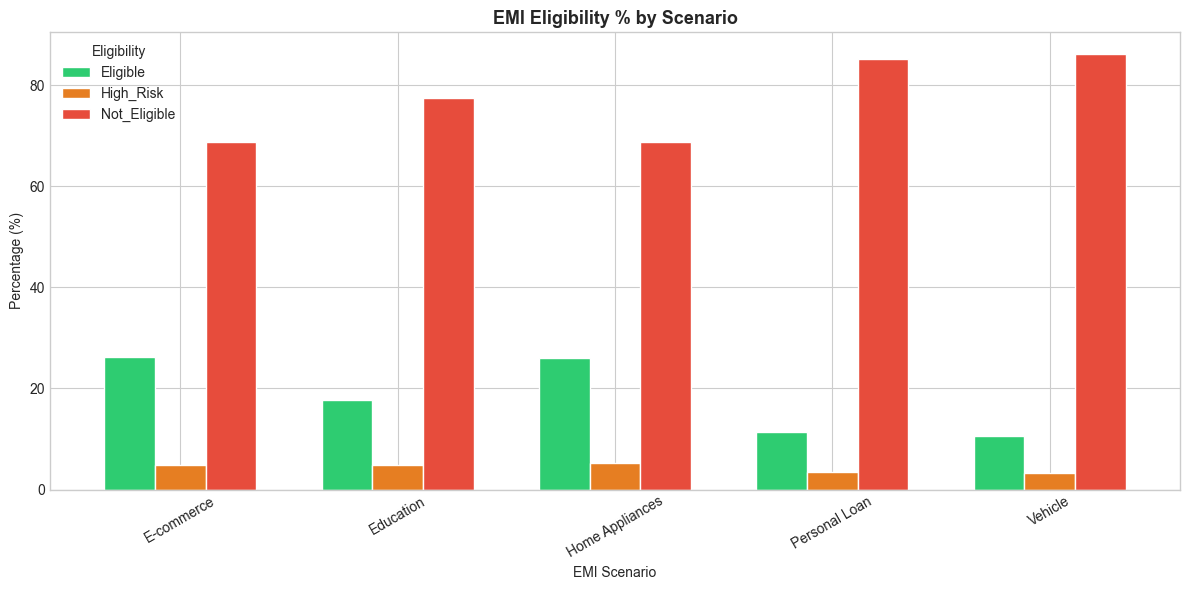

In [ ]:
# Eligibility by EMI
fig, ax = plt.subplots(figsize=(12, 6))

scenario_eligibility = df.groupby(['scenario_label', 'emi_eligibility_label']).size().unstack()
scenario_eligibility_pct = scenario_eligibility.div(scenario_eligibility.sum(axis=1), axis=0) * 100

scenario_eligibility_pct.plot(
    kind='bar',
    ax=ax,
    color=['#2ecc71', '#e77e22', '#e74c3c'],
    edgecolor='white',
    width=0.7
)

ax.set_title('EMI Eligibility % by Scenario', fontsize=13, fontweight='bold')
ax.set_xlabel('EMI Scenario')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Eligibility')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../data/processed/eligibility_by_scenario.png', dpi=120)
plt.show()

In [11]:
# Extract class distribution number
print("EMI Eligibility Class Distribution:")
print("-" * 40)
counts = df['emi_eligibility_label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<15} : {count:>7,} ({count/len(df)*100:.1f}%)")

print(f"\nTotal records : {len(df):,}")
print("\nIMBALANCE NOTE: Not_Eligible class is dominant.")
print("We will use class_weight='balanced' in ML models.")

EMI Eligibility Class Distribution:
----------------------------------------
  Not_Eligible    : 312,868 (77.3%)
  Eligible        :  74,444 (18.4%)
  High_Risk       :  17,488 (4.3%)

Total records : 404,800

IMBALANCE NOTE: Not_Eligible class is dominant.
We will use class_weight='balanced' in ML models.


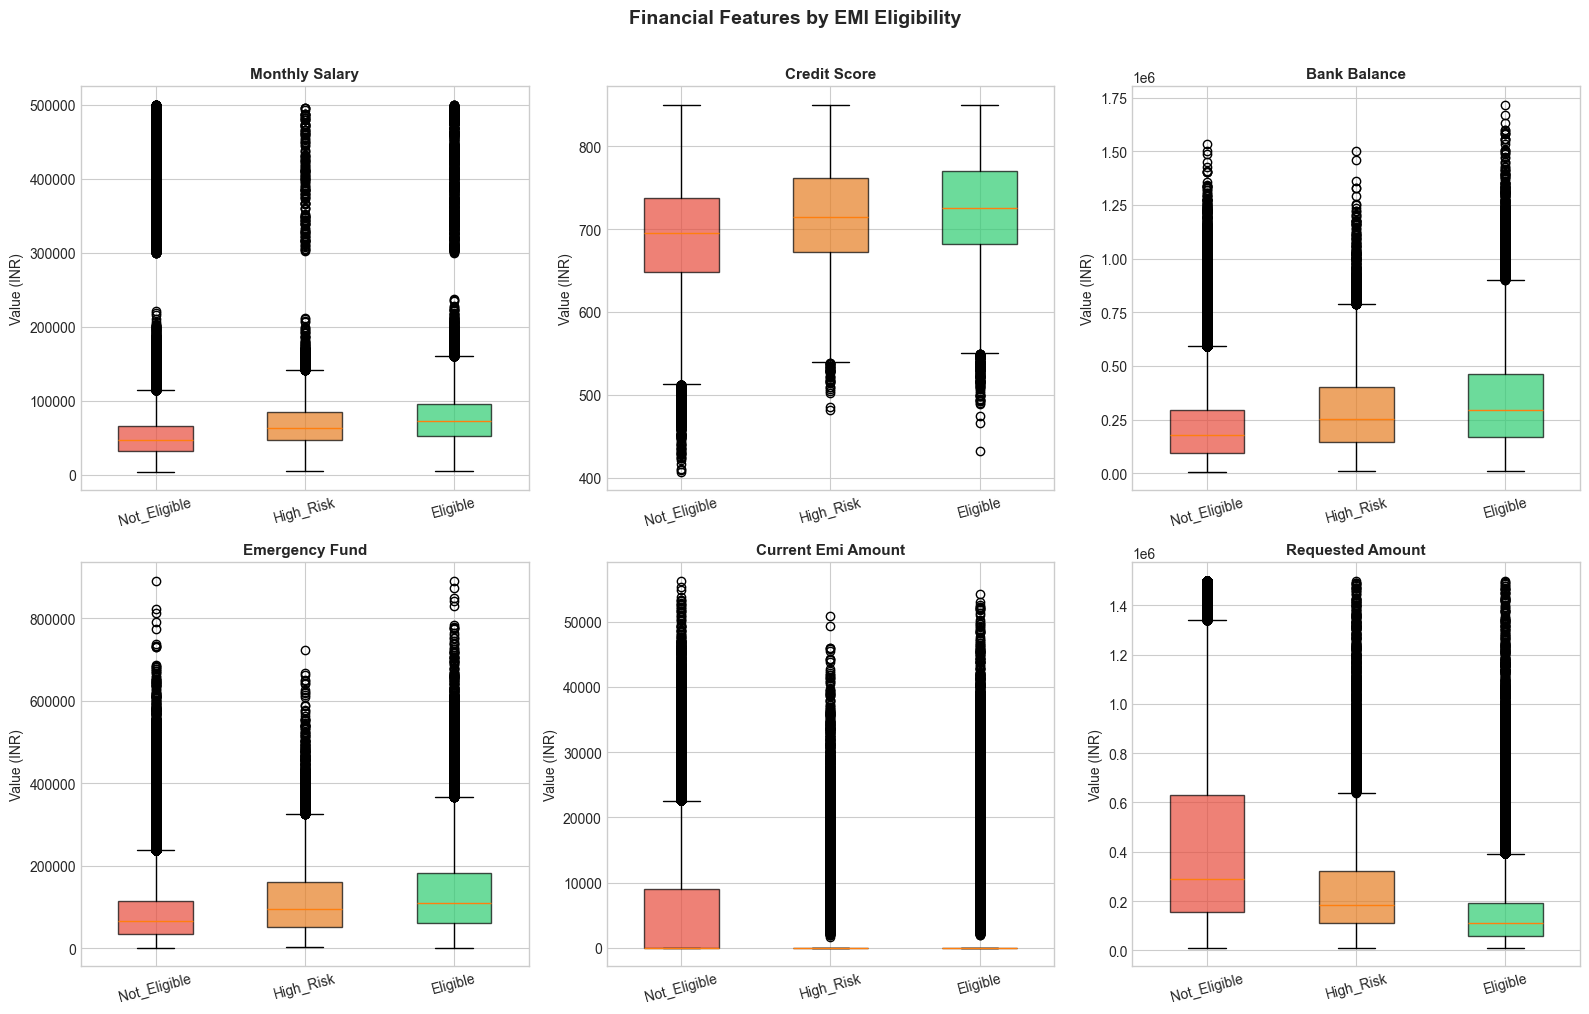

In [12]:
# key financial features by eligibility
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

financial_features = [
    'monthly_salary', 'credit_score', 'bank_balance',
    'emergency_fund', 'current_emi_amount', 'requested_amount'
]

colors = ['#e74c3c', '#e67e22', '#2ecc71']
labels = ['Not_Eligible', 'High_Risk', 'Eligible']

for i, feat in enumerate(financial_features):
    data_to_plot = [
        df[df['emi_eligibility_label'] == label][feat].dropna()
        for label in labels
    ]
    bp = axes[i].boxplot(
        data_to_plot,
        patch_artist=True,
        labels=labels,
        widths=0.5
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value (INR)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Financial Features by EMI Eligibility', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/boxplots_by_eligibility.png', dpi=120)
plt.show()

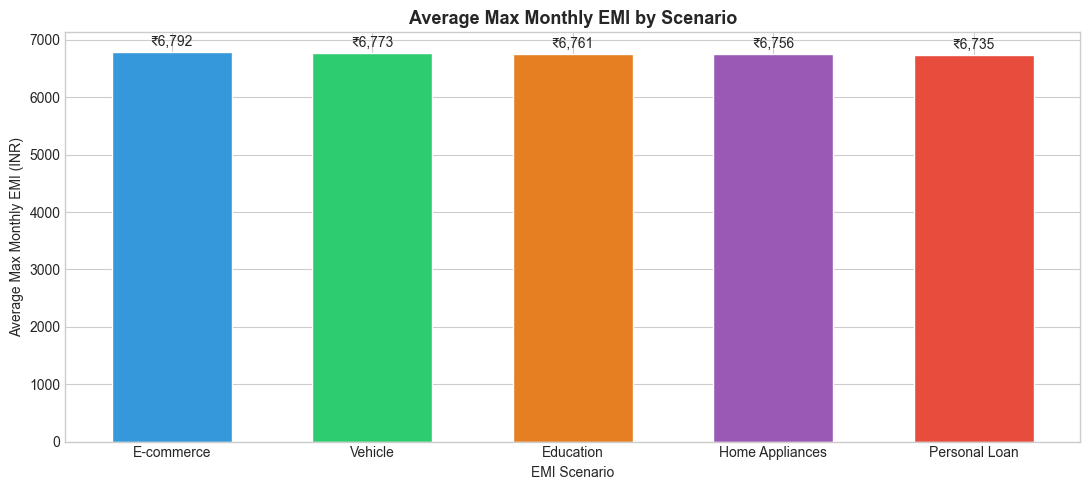

In [13]:
# MAx monthly EMI by scenario
fig, ax = plt.subplots(figsize=(11, 5))

scenario_emi = df.groupby('scenario_label')['max_monthly_emi'].mean().sort_values(ascending=False)

bars = ax.bar(
    scenario_emi.index,
    scenario_emi.values,
    color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c'],
    edgecolor='white',
    width=0.6
)

for bar, val in zip(bars, scenario_emi.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'₹{val:,.0f}',
        ha='center', fontsize=10
    )

ax.set_title('Average Max Monthly EMI by Scenario', fontsize=13, fontweight='bold')
ax.set_xlabel('EMI Scenario')
ax.set_ylabel('Average Max Monthly EMI (INR)')
plt.tight_layout()
plt.savefig('../data/processed/avg_emi_by_scenario.png', dpi=120)
plt.show()

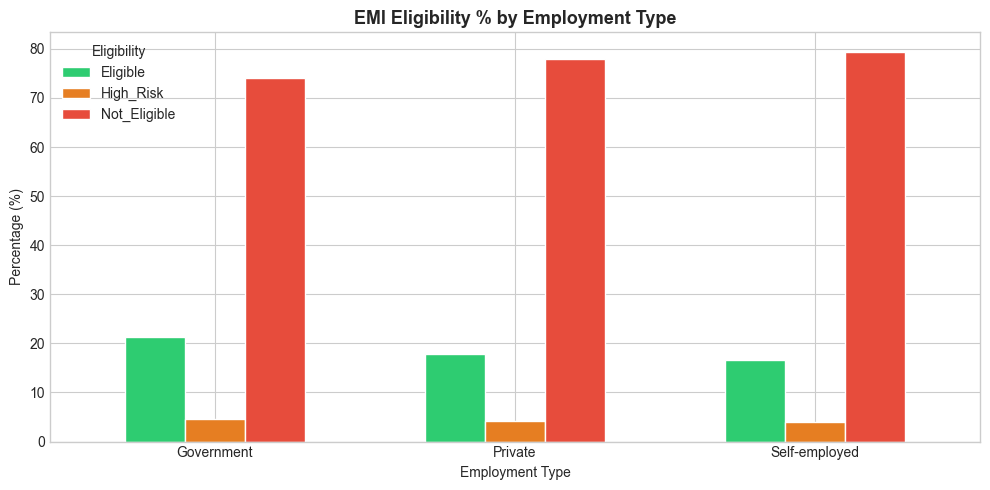

In [14]:
# Employment type Vs Eligibility
fig, ax = plt.subplots(figsize=(10, 5))

emp_map = {0: 'Private', 1: 'Government', 2: 'Self-employed'}
df['employment_label'] = df['employment_type'].map(emp_map)

emp_elig = df.groupby(['employment_label', 'emi_eligibility_label']).size().unstack()
emp_elig_pct = emp_elig.div(emp_elig.sum(axis=1), axis=0) * 100

emp_elig_pct.plot(
    kind='bar',
    ax=ax,
    color=['#2ecc71', '#e67e22', '#e74c3c'],
    edgecolor='white',
    width=0.6
)

ax.set_title('EMI Eligibility % by Employment Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Employment Type')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Eligibility')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/eligibility_by_employment.png', dpi=120)
plt.show()

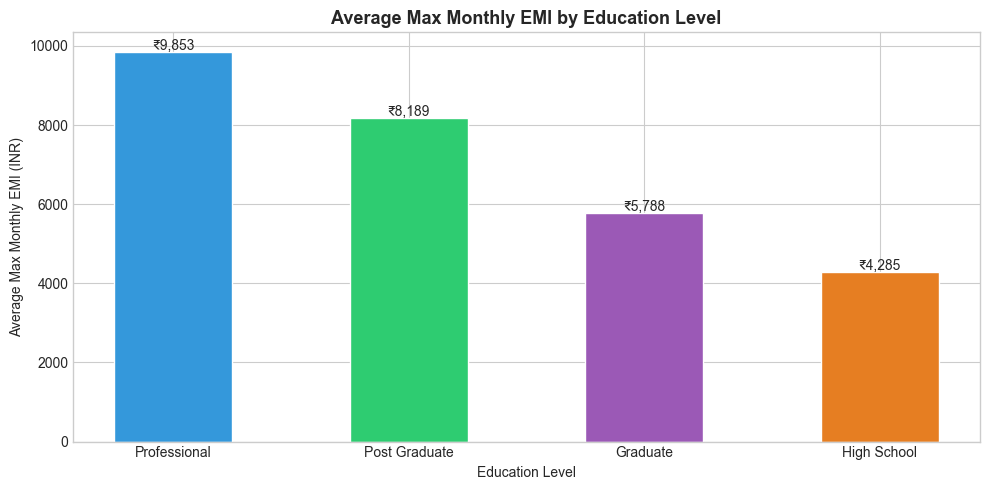

In [15]:
# Education vs Max average EMI
fig, ax = plt.subplots(figsize=(10, 5))

edu_map = {0: 'High School', 1: 'Graduate', 2: 'Post Graduate', 3: 'Professional'}
df['education_label'] = df['education'].map(edu_map)

edu_emi = df.groupby('education_label')['max_monthly_emi'].mean().sort_values(ascending=False)

bars = ax.bar(
    edu_emi.index,
    edu_emi.values,
    color=['#3498db', '#2ecc71', '#9b59b6', '#e67e22'],
    edgecolor='white',
    width=0.5
)

for bar, val in zip(bars, edu_emi.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'₹{val:,.0f}',
        ha='center', fontsize=10
    )

ax.set_title('Average Max Monthly EMI by Education Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('Average Max Monthly EMI (INR)')
plt.tight_layout()
plt.savefig('../data/processed/emi_by_education.png', dpi=120)
plt.show()

In [16]:
# EMIsummary
print("=" * 55)
print("  EDA BUSINESS INSIGHTS SUMMARY")
print("=" * 55)
print("""
1. CLASS IMBALANCE
   → Not_Eligible class dominates the dataset
   → Will use class_weight='balanced' in all models

2. SALARY & ELIGIBILITY
   → Higher salary strongly linked to Eligible class
   → Low salary customers mostly Not_Eligible

3. CREDIT SCORE
   → Eligible customers have clearly higher credit scores
   → Strong predictor for classification model

4. BANK BALANCE & EMERGENCY FUND
   → Highly correlated (0.89) with each other
   → Both positively linked to higher max EMI

5. HOUSE TYPE & RENT
   → Negatively correlated (-0.70)
   → Own house = zero rent = more EMI capacity

6. FAMILY SIZE & DEPENDENTS
   → Perfectly correlated (1.00) — dropped family_size

7. VEHICLE EMI
   → Highest average max monthly EMI among all scenarios
   → Education EMI has lowest average

8. GOVERNMENT EMPLOYEES
   → Slightly better eligibility than private/self-employed
   → More stable income = lower risk
""")
print("=" * 55)
print("✅ Notebook 2 Complete — Ready for Feature Engineering")
print("=" * 55)

  EDA BUSINESS INSIGHTS SUMMARY

1. CLASS IMBALANCE
   → Not_Eligible class dominates the dataset
   → Will use class_weight='balanced' in all models

2. SALARY & ELIGIBILITY
   → Higher salary strongly linked to Eligible class
   → Low salary customers mostly Not_Eligible

3. CREDIT SCORE
   → Eligible customers have clearly higher credit scores
   → Strong predictor for classification model

4. BANK BALANCE & EMERGENCY FUND
   → Highly correlated (0.89) with each other
   → Both positively linked to higher max EMI

5. HOUSE TYPE & RENT
   → Negatively correlated (-0.70)
   → Own house = zero rent = more EMI capacity

6. FAMILY SIZE & DEPENDENTS
   → Perfectly correlated (1.00) — dropped family_size

7. VEHICLE EMI
   → Highest average max monthly EMI among all scenarios
   → Education EMI has lowest average

8. GOVERNMENT EMPLOYEES
   → Slightly better eligibility than private/self-employed
   → More stable income = lower risk

✅ Notebook 2 Complete — Ready for Feature Engineering
